In [2]:
#!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn joblib tldextract requests tranco  tqdm rapidfuzz

In [3]:
import os
import re
import math
import joblib
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.base import clone
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix
from catboost import CatBoostClassifier
import tldextract
from sklearn.feature_extraction.text import TfidfVectorizer
import math
import re
from urllib.parse import urlparse, parse_qs
import tldextract
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [47]:
import joblib
import sklearn
print("scikit-learn version:", sklearn.__version__)
print(joblib.__version__)

scikit-learn version: 1.9.0
1.5.3


In [4]:
import json
from tranco import Tranco
from rapidfuzz.distance import Levenshtein
from rapidfuzz.fuzz import ratio

TRANCO_MAX = 1000000

t = Tranco(cache=True)
latest = t.list()

tranco_domains = latest.top(TRANCO_MAX)

known_domains_snapshot = set(tranco_domains)

known_domain_txt = os.path.abspath("../phishing_model/known_domains.txt")
with open(known_domain_txt, "w") as f:
    for domain in known_domains_snapshot:
        f.write(domain + "\n")

with open(known_domain_txt, "r") as f:
    known_domains_snapshot = set(line.strip() for line in f)

In [ ]:
MIN_BRAND_LEN_FOR_FUZZY = 5   # brands shorter than this only get exact/

data_json_path = os.path.abspath("../phishing_model/data.json")

def shannon_entropy(s):
        if not s:
            return 0.0
        probs = [s.count(c) / len(s) for c in set(s)]
        return -sum(p * math.log2(p) for p in probs)

with open(data_json_path, "r") as f:
    data = json.load(f)
    brand_data = data.get("brands", {})
    suspicious_keywords = set(data.get("suspicious_keywords", []))
    url_shorteners = set(data.get("url_shorteners", []))
    popular_tlds = set(data.get("tlds", []))


def brand_lookalike(domain_str, brand_set, ratio_threshold=0.82, max_edit_distance=2):
        if not domain_str or domain_str in brand_set:
            return None, 0.0
        best_brand, best_ratio = None, 0.0
        for b in brand_set:
            if len(b) < MIN_BRAND_LEN_FOR_FUZZY:
                continue   # skip short brands entirely for fuzzy matching

            similarity = ratio(domain_str, b) / 100.0
            if similarity < ratio_threshold:
                continue
            edit_dist = Levenshtein.distance(domain_str, b)
            if edit_dist > max_edit_distance:
                continue

            if similarity > best_ratio:
                best_brand, best_ratio = b, similarity
        return best_brand , best_ratio

def extract_features_from_url(url: str):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    # Domain-only 
    domain_url = f"{parsed.scheme}://{parsed.netloc}"

    domain = ext.domain or ""
    suffix = ext.suffix or ""
    subdomain = ext.subdomain or ""
    subdomain = ".".join(p for p in subdomain.split(".") if p and p != "www")
    full_domain = ".".join(x for x in [subdomain, domain, suffix] if x)

    url_length = len(domain_url)

    
    # Tokenization — hostname only (computed once, reused everywhere)
    
    hostname_tokens = [t.lower() for t in re.split(r"[.-]", full_domain) if t]
    joined_hostname_text = " ".join(hostname_tokens)

    
    # Entropy
    
    

    url_entropy = shannon_entropy(domain_url)
    hostname_entropy = shannon_entropy(full_domain)

    
    # Domain features
    
    has_ip_address = int(bool(re.search(r"(\d{1,3}\.){3}\d{1,3}", full_domain)))
    dot_count = domain_url.count(".")
    https_flag = int(parsed.scheme == "https")
    token_count = len(re.split(r"\W+", domain_url))
    subdomain_count = len([x for x in subdomain.split(".") if x]) if subdomain else 0
    tld_length = len(suffix)
    has_hyphen_in_domain = int("-" in full_domain)
    number_of_digits = sum(c.isdigit() for c in domain_url)
    tld_popularity = int(suffix in popular_tlds)
    domain_name_length = len(domain)

    
    # Character ratios
    # letter_ratio + digit_ratio + "special" ratio always sum to 1
    
    letters = sum(c.isalpha() for c in domain_url)
    letter_ratio = letters / url_length if url_length else 0
    digit_ratio = number_of_digits / url_length if url_length else 0

    
    # Hostname statistics
    
    hostname_token_count = len(hostname_tokens)
    avg_hostname_token_length = (
        sum(len(t) for t in hostname_tokens) / hostname_token_count
        if hostname_token_count else 0
    )
    longest_hostname_token = max((len(t) for t in hostname_tokens), default=0)

    
    # Brand features
    
    brands = set(brand_data.keys())

    found_brands = [b for b in brands if b in joined_hostname_text]
    brand_in_registered_domain = int(domain.lower() in brands)
    brand_only_in_subdomain = int(
        len(found_brands) > 0 and not brand_in_registered_domain
    )

    

    lookalike_brand, brand_similarity = brand_lookalike(domain.lower(), brands)
    brand_lookalike_flag = int(lookalike_brand is not None)

    effective_brands = set(found_brands)
    if lookalike_brand:
        effective_brands.add(lookalike_brand)

    contains_brand = int(len(effective_brands) > 0)   
    brand_count = len(effective_brands)

    brand_phishing_rank = 0
    if effective_brands:
        brand_phishing_rank = min(
            brand_data[b].get("rank", 99)
            for b in effective_brands if b in brand_data
        )

    
    # Keyword features — hostname only
    
    keyword_count = sum(1 for kw in suspicious_keywords if kw in joined_hostname_text)
    brand_keyword_combo = int(contains_brand and keyword_count > 0)

    at_symbol_count = domain_url.count("@")
    is_shortened = int(full_domain in url_shorteners)
    has_punycode = int("xn--" in full_domain)

    
    # Known-phishing-domain similarity 
    
    matched_known_phishing_domain = 0
    known_phishing_domain_similarity = 0.0
    if effective_brands:
        all_known_domains = []
        for b in effective_brands:
            all_known_domains.extend(brand_data.get(b, {}).get("phishing_domains", []))
        for known_domain in all_known_domains:
            if full_domain == known_domain:
                matched_known_phishing_domain = 1
            similarity = ratio(full_domain, known_domain) / 100.0
            known_phishing_domain_similarity = max(known_phishing_domain_similarity, similarity)

    
    # Digit run
    
    max_digit_run = 0
    current = 0
    for c in domain_url:
        if c.isdigit():
            current += 1
            max_digit_run = max(max_digit_run, current)
        else:
            current = 0

    
    # Domain reputation — module-level `known_domains_snapshot`, loaded
    
    is_known_domain = int(full_domain in known_domains_snapshot)

    return {
        "url_length": url_length,
        "has_ip_address": has_ip_address,
        "dot_count": dot_count,
        "https_flag": https_flag,
        "url_entropy": url_entropy,
        "token_count": token_count,
        "subdomain_count": subdomain_count,
        "tld_length": tld_length,
        "has_hyphen_in_domain": has_hyphen_in_domain,
        "number_of_digits": number_of_digits,
        "tld_popularity": tld_popularity,
        "domain_name_length": domain_name_length,

        "hostname_entropy": hostname_entropy,

        "letter_ratio": letter_ratio,
        "digit_ratio": digit_ratio,

        "hostname_token_count": hostname_token_count,
        "avg_hostname_token_length": avg_hostname_token_length,
        "longest_hostname_token": longest_hostname_token,

        "brand_count": brand_count,
        "brand_in_registered_domain": brand_in_registered_domain,
        "brand_only_in_subdomain": brand_only_in_subdomain,

        "keyword_count": keyword_count,
        "brand_keyword_combo": brand_keyword_combo,

        "max_digit_run": max_digit_run,
        "at_symbol_count": at_symbol_count,
        "is_shortened": is_shortened,
        "has_punycode": has_punycode,
        "brand_phishing_rank": brand_phishing_rank,
        "matched_known_phishing_domain": matched_known_phishing_domain,
        "known_phishing_domain_similarity": known_phishing_domain_similarity,
        "brand_lookalike_flag": brand_lookalike_flag,
        "brand_similarity": brand_similarity,
        "is_known_domain": is_known_domain,

        "_registered_domain": f"{domain}.{suffix}" if suffix else domain,
    }

In [6]:
#Data Collection from LegitPhish, OpenPhish, PhishTank, and Cisco Umbrella —
#collect everything first, dedupe, balance classes, THEN extract features once.

import random
from urllib.parse import urlparse, urlsplit, urlunsplit, parse_qsl, urlencode
import pandas as pd
import requests
from tqdm import tqdm
import os
import tldextract
import zipfile
import io

URL_COL = 'URL'
LABEL_COL = 'ClassLabel'
REGISTERED_DOMAIN_COL = '_registered_domain'

MAX_PHISH = 150000
MAX_UMBRELLA = 150000
TARGET_LEGIT_TO_PHISH_RATIO = 1.5   # tune this — controls final class balance

PHISHTANK_URL = "http://data.phishtank.com/data/online-valid.csv"
PHISHTANK_FILE = os.path.abspath("../dataset/phishtank.csv")
LEGITPHISH_FILE = os.path.abspath("../dataset/LegitPhish.csv")

UMBRELLA_URL = "https://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip"
UMBRELLA_CACHE = os.path.abspath("../dataset/umbrella_top1m.csv")

OUTPUT_FILE = "dataset.csv"
FAILED_FILE = "failed_urls.csv"


def is_valid_url(url):
    try:
        p = urlparse(str(url).strip())
        return p.scheme in ("http", "https") and bool(p.netloc)
    except Exception:
        return False


def normalize(url):
    """Normalize URLs — strip path/query, keep only scheme + netloc."""
    try:
        url = str(url).strip().lower()
        p = urlsplit(url)
        scheme = p.scheme
        netloc = p.netloc.rstrip(".")
        if scheme == "http" and netloc.endswith(":80"):
            netloc = netloc[:-3]
        elif scheme == "https" and netloc.endswith(":443"):
            netloc = netloc[:-4]
        return f"{scheme}://{netloc}"
    except Exception:
        return str(url).strip().lower()


def get_registered_domain(url):
    try:
        ext = tldextract.extract(url)
        domain = ext.domain or ""
        suffix = ext.suffix or ""
        return f"{domain}.{suffix}" if suffix else domain
    except Exception:
        return ""


def download_umbrella_list(force=False):
    if os.path.exists(UMBRELLA_CACHE) and not force:
        print("Using cached Umbrella list:", UMBRELLA_CACHE)
        return pd.read_csv(UMBRELLA_CACHE, names=["rank", "hostname"])

    print("Downloading Cisco Umbrella top-1m list...")
    resp = requests.get(UMBRELLA_URL, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        inner_name = z.namelist()[0]
        with z.open(inner_name) as f:
            df_umbrella = pd.read_csv(f, names=["rank", "hostname"])
    df_umbrella.to_csv(UMBRELLA_CACHE, index=False, header=False)
    print(f"Downloaded and cached {len(df_umbrella)} entries.")
    return df_umbrella


def is_valid_umbrella_hostname(hostname):
    try:
        ext = tldextract.extract(hostname)
        return bool(ext.domain) and bool(ext.suffix)
    except Exception:
        return False



# 1. LOAD LegitPhish (raw URLs + labels only — no feature extraction yet)

print("=" * 60)
print("Loading LegitPhish dataset...")
print("=" * 60)

if not os.path.exists(LEGITPHISH_FILE):
    raise FileNotFoundError(f"{LEGITPHISH_FILE} not found. Upload dataset to this path.")

df_legit_phish = pd.read_csv(LEGITPHISH_FILE)
df_legit_phish = df_legit_phish.dropna(subset=[URL_COL, LABEL_COL]).copy()
df_legit_phish[URL_COL] = df_legit_phish[URL_COL].astype(str).apply(normalize)
df_legit_phish[LABEL_COL] = pd.to_numeric(df_legit_phish[LABEL_COL], errors="coerce")
df_legit_phish = df_legit_phish.dropna(subset=[LABEL_COL])
df_legit_phish[LABEL_COL] = df_legit_phish[LABEL_COL].astype(int)
df_legit_phish = df_legit_phish.drop_duplicates(subset=[URL_COL], keep="first").reset_index(drop=True)

print(f"LegitPhish: {len(df_legit_phish)} rows "
      f"(legit={ (df_legit_phish[LABEL_COL]==1).sum() }, "
      f"phish={ (df_legit_phish[LABEL_COL]==0).sum() })")

legitphish_pairs = list(zip(df_legit_phish[URL_COL], df_legit_phish[LABEL_COL]))



# 2. DOWNLOAD OpenPhish

print("\n" + "=" * 60)
print("Downloading OpenPhish...")
print("=" * 60)
try:
    openphish_urls = requests.get("https://openphish.com/feed.txt", timeout=30).text.splitlines()
except Exception as e:
    print("OpenPhish failed:", e)
    openphish_urls = []
print(f"OpenPhish URLs : {len(openphish_urls)}")



# 3. DOWNLOAD PhishTank

print("\nLoading PhishTank...")
try:
    phishtank = pd.read_csv(PHISHTANK_URL)
except Exception as e:
    phishtank = pd.read_csv(PHISHTANK_FILE)
if "url" not in phishtank.columns:
    raise ValueError("Expected column 'url' in phishtank.csv")
phishtank_urls = phishtank["url"].dropna().astype(str).tolist()
print(f"PhishTank URLs : {len(phishtank_urls)}")



# 4. DOWNLOAD Cisco Umbrella Top 1M

print("\nDownloading Cisco Umbrella...")
umbrella_df = download_umbrella_list()
umbrella_df = umbrella_df[umbrella_df["hostname"].apply(is_valid_umbrella_hostname)]
umbrella_urls = ("https://" + umbrella_df["hostname"].astype(str)).tolist()
print(f"Umbrella URLs : {len(umbrella_urls)}")



# 5. COMBINE ALL SOURCES INTO ONE RAW (url, label) POOL — no feature
# extraction yet. Priority order for dedup: LegitPhish.csv (curated,
# most trustworthy labels) > PhishTank/OpenPhish (real reported phishing)
# > Umbrella (bulk legit source, least curated) — first occurrence wins.

print("\n" + "=" * 60)
print("Combining all sources...")
print("=" * 60)

seen_urls = set()
all_pairs = []   # list of (url, label)

def add_pairs(url_iterable, label, seen, out):
    added = 0
    for u in url_iterable:
        if not is_valid_url(u):
            continue
        u = normalize(u)
        if u in seen:
            continue
        seen.add(u)
        out.append((u, label))
        added += 1
    return added

# 1) LegitPhish first — highest priority, already has explicit labels
for u, lbl in legitphish_pairs:
    if u in seen_urls:
        continue
    seen_urls.add(u)
    all_pairs.append((u, lbl))
print(f"After LegitPhish: {len(all_pairs)} URLs")

# 2) Phishing sources (label 0) — capped at MAX_PHISH
phish_pool = []
add_pairs(openphish_urls + phishtank_urls, 0, seen_urls, phish_pool)
phish_pool = phish_pool[:MAX_PHISH]
all_pairs.extend(phish_pool)
print(f"After phishing sources: {len(all_pairs)} URLs "
      f"({len(phish_pool)} new phishing, capped at {MAX_PHISH})")

# 3) Umbrella (label 1) — capped at MAX_UMBRELLA
legit_pool = []
add_pairs(umbrella_urls, 1, seen_urls, legit_pool)
legit_pool = legit_pool[:MAX_UMBRELLA]
all_pairs.extend(legit_pool)
print(f"After Umbrella: {len(all_pairs)} URLs "
      f"({len(legit_pool)} new legit, capped at {MAX_UMBRELLA})")



# 6. RESOLVE CLASS IMBALANCE — cap the majority class by random sampling,
# BEFORE feature extraction (saves compute on rows we'd discard anyway).

print("\n" + "=" * 60)
print("Resolving class imbalance...")
print("=" * 60)

phish_rows = [p for p in all_pairs if p[1] == 0]
legit_rows = [p for p in all_pairs if p[1] == 1]
print(f"Pre-balance — legit: {len(legit_rows)}, phishing: {len(phish_rows)}, "
      f"ratio: {len(legit_rows) / max(len(phish_rows),1):.2f}:1")

rng = random.Random(RANDOM_STATE)
max_legit = int(len(phish_rows) * TARGET_LEGIT_TO_PHISH_RATIO)
if len(legit_rows) > max_legit:
    legit_rows = rng.sample(legit_rows, max_legit)

all_pairs = legit_rows + phish_rows
rng.shuffle(all_pairs)

print(f"Post-balance — legit: {len(legit_rows)}, phishing: {len(phish_rows)}, "
      f"ratio: {len(legit_rows) / max(len(phish_rows),1):.2f}:1")
print(f"Total URLs going into feature extraction: {len(all_pairs)}")



# 7. EXTRACT FEATURES ONCE, over the final balanced+deduped pool

print("\n" + "=" * 60)
print("Extracting features (single pass, all sources)...")
print("=" * 60)

rows = []
failed = []

for url, label in tqdm(all_pairs, desc="Extracting features"):
    try:
        feat = extract_features_from_url(url)
        if feat is None:
            failed.append(url)
            continue
        feat[URL_COL] = url
        feat[LABEL_COL] = label
        rows.append(feat)
    except Exception:
        failed.append(url)

print(f"\nSuccessfully extracted features for {len(rows)} URLs. Failed: {len(failed)}")
if failed:
    pd.Series(failed, name="url").to_csv(FAILED_FILE, index=False)
    print(f"Failed URLs saved to {FAILED_FILE}")



# 8. FINAL DATAFRAME

print("\n" + "=" * 60)
print("Building final dataset...")
print("=" * 60)

df = pd.DataFrame(rows)
df[REGISTERED_DOMAIN_COL] = df[URL_COL].apply(get_registered_domain)

# Shuffle again post-DataFrame construction (belt-and-suspenders — rows
# were already shuffled at the pair-list stage in Step 6)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("=" * 60)
print("Combined Dataset Summary")
print("=" * 60)
print(f"Total Rows : {len(df)}")
print("\nClass Distribution:")
print(df[LABEL_COL].value_counts())
print(f"\nRatio (legit:phish): "
      f"{(df[LABEL_COL]==1).sum() / max((df[LABEL_COL]==0).sum(),1):.2f}:1")

df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved to {OUTPUT_FILE}")

Loading LegitPhish dataset...
LegitPhish: 64151 rows (legit=37113, phish=27038)

OpenPhish URLs : 300

Loading PhishTank...
PhishTank URLs : 65213

Using cached Umbrella list: c:\Users\ASUS\Documents\Projects\aegis-project\backend\app\dataset\umbrella_top1m.csv
Umbrella URLs : 1000000

Combining all sources...
After LegitPhish: 64151 URLs
After phishing sources: 98546 URLs (34395 new phishing, capped at 150000)
After Umbrella: 248546 URLs (150000 new legit, capped at 150000)

Resolving class imbalance...
Pre-balance — legit: 187113, phishing: 61433, ratio: 3.05:1
Post-balance — legit: 92149, phishing: 61433, ratio: 1.50:1
Total URLs going into feature extraction: 153582

Extracting features (single pass, all sources)...


Extracting features: 100%|██████████| 153582/153582 [00:10<00:00, 14467.49it/s]



Successfully extracted features for 153582 URLs. Failed: 0

Building final dataset...
Combined Dataset Summary
Total Rows : 153582

Class Distribution:
ClassLabel
1    92149
0    61433
Name: count, dtype: int64

Ratio (legit:phish): 1.50:1

Saved to dataset.csv


In [7]:
FEATURE_COLS = df.columns.difference([URL_COL, LABEL_COL, REGISTERED_DOMAIN_COL]).tolist()

print("Label column:", LABEL_COL)
print("Feature columns being used:", FEATURE_COLS)

Label column: ClassLabel
Feature columns being used: ['at_symbol_count', 'avg_hostname_token_length', 'brand_count', 'brand_in_registered_domain', 'brand_keyword_combo', 'brand_lookalike_flag', 'brand_only_in_subdomain', 'brand_phishing_rank', 'brand_similarity', 'digit_ratio', 'domain_name_length', 'dot_count', 'has_hyphen_in_domain', 'has_ip_address', 'has_punycode', 'hostname_entropy', 'hostname_token_count', 'https_flag', 'is_known_domain', 'is_shortened', 'keyword_count', 'known_phishing_domain_similarity', 'letter_ratio', 'longest_hostname_token', 'matched_known_phishing_domain', 'max_digit_run', 'number_of_digits', 'subdomain_count', 'tld_length', 'tld_popularity', 'token_count', 'url_entropy', 'url_length']


In [8]:
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors='coerce')
print("Label NaNs before:", df[LABEL_COL].isna().sum())
df = df[df[LABEL_COL].notna()].copy() # Keep only rows with valid labels
df[LABEL_COL] = df[LABEL_COL].astype(int)
print("Label distribution:\n", df[LABEL_COL].value_counts())

for c in FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    n_missing = df[c].isna().sum()
    if n_missing > 0:
        print(f"  {c}: filling {n_missing} missing values with median")
        med = df[c].median()
        df[c] = df[c].fillna(med)
print("Any feature NaNs left:", df[FEATURE_COLS].isnull().sum().sum())
display(df.head(3))


Label NaNs before: 0
Label distribution:
 ClassLabel
1    92149
0    61433
Name: count, dtype: int64
Any feature NaNs left: 0


,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,tld_length,has_hyphen_in_domain,number_of_digits,...,has_punycode,brand_phishing_rank,matched_known_phishing_domain,known_phishing_domain_similarity,brand_lookalike_flag,brand_similarity,is_known_domain,_registered_domain,URL,ClassLabel
0,27,1,3,0,3.708048,6,0,0,0,16,...,0,0,0,0.0,0,0.0,0,117.213.92.239,http://117.213.92.239:48676,0
1,23,0,1,1,3.795089,4,0,3,1,0,...,0,0,0,0.0,0,0.0,1,gannett-cdn.com,https://gannett-cdn.com,1
2,32,0,2,1,4.327820,5,1,3,1,5,...,0,0,0,0.0,0,0.0,0,firebaseapp.com,https://sk-39498.firebaseapp.com,0


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Drop rows where the domain or URL is missing
df_filtered = df.dropna(subset=['_registered_domain', URL_COL]).copy()

# 2. FORCE the groups to be clean strings (fixes the float64/inf issue entirely)
groups = df_filtered['_registered_domain'].astype(str).str.strip()
valid_mask = groups.notna() & (groups != "") & (groups != "nan") & (groups.str.lower() != "inf")

# 3. Apply the mask to get our final clean datasets
X = df_filtered.loc[valid_mask, FEATURE_COLS].copy()
y = df_filtered.loc[valid_mask, LABEL_COL].copy()
groups = groups.loc[valid_mask]

# Make sure '_registered_domain' isn't accidentally in your feature columns
if '_registered_domain' in X.columns:
    X = X.drop(columns=['_registered_domain'])

print(f"Data prepared: {len(X)} samples, {groups.nunique()} unique groups")

# 4. Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train/Test shapes:", X_train.shape, X_test.shape)
print("Unique domains — train:", groups.iloc[train_idx].nunique(), "test:", groups.iloc[test_idx].nunique())

url_all = df_filtered.loc[valid_mask, URL_COL].copy()
url_train, url_test = url_all.iloc[train_idx], url_all.iloc[test_idx]
 
print("URL series aligned:", url_train.shape, url_test.shape)

Data prepared: 153576 samples, 72062 unique groups
Train/Test shapes: (121304, 33) (32272, 33)
Unique domains — train: 57649 test: 14413
URL series aligned: (121304,) (32272,)


In [10]:
cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=0,
    auto_class_weights='Balanced'
)

ext = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=12,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

base_models = [cat, ext, rf]
print("Base models:", [m.__class__.__name__ for m in base_models])

tfidf_lr = LogisticRegression(
    solver='lbfgs',
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

Base models: ['CatBoostClassifier', 'ExtraTreesClassifier', 'RandomForestClassifier']


In [11]:
base_model_specs = [
    {'name': 'cat', 'type': 'numeric', 'estimator': cat},
    {'name': 'ext', 'type': 'numeric', 'estimator': ext},
    {'name': 'rf',  'type': 'numeric', 'estimator': rf},
    {'name': 'tfidf_lr', 'type': 'text', 'estimator': tfidf_lr},
]
print("Base models:", [s['name'] for s in base_model_specs])

Base models: ['cat', 'ext', 'rf', 'tfidf_lr']


In [12]:
HOMOGLYPH_WEIGHT = 4.0 

def compute_sample_weights(X_df, y_ser):
    w = np.ones(len(X_df))
    mask = (X_df["brand_lookalike_flag"].values == 1) & (y_ser.values == 0)
    w[mask] = HOMOGLYPH_WEIGHT
    return w

In [13]:
from sklearn.model_selection import StratifiedKFold

def get_oof_preds_mixed(model_specs, X_df, y_ser, url_ser=None,
                         X_holdout_df=None, url_holdout=None,
                         n_splits=5, random_state=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    n = X_df.shape[0]
    m = len(model_specs)
    oof_train = np.zeros((n, m))
    holdout_preds = np.zeros((X_holdout_df.shape[0], m)) if X_holdout_df is not None else None
 
    full_weights = compute_sample_weights(X_df, y_ser)   # <-- NEW
 
    for i, spec in enumerate(model_specs):
        name, mtype, model = spec['name'], spec['type'], spec['estimator']
        print(f"Generating OOF for model {i+1}/{m}: {name} ({mtype})")
        oof_model = np.zeros(n)
        holdout_fold_preds = (np.zeros((X_holdout_df.shape[0], n_splits))
                               if X_holdout_df is not None else None)
 
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_df, y_ser)):
            y_tr = y_ser.iloc[tr_idx]
            w_tr = full_weights[tr_idx]   # <-- NEW: sliced per fold
 
            if mtype == 'text':
                url_tr, url_val = url_ser.iloc[tr_idx], url_ser.iloc[val_idx]
                vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                                       max_features=20000, min_df=2)
                Xtr_t = vec.fit_transform(url_tr.astype(str))
                Xval_t = vec.transform(url_val.astype(str))
                m_clone = clone(model)
                m_clone.fit(Xtr_t, y_tr, sample_weight=w_tr)   # <-- weighted
                oof_model[val_idx] = m_clone.predict_proba(Xval_t)[:, 1]
                if url_holdout is not None:
                    holdout_fold_preds[:, fold] = m_clone.predict_proba(
                        vec.transform(url_holdout.astype(str)))[:, 1]
            else:
                X_tr, X_val = X_df.iloc[tr_idx], X_df.iloc[val_idx]
                m_clone = clone(model)
                if isinstance(m_clone, LogisticRegression):
                    scaler_local = StandardScaler()
                    X_tr_sc = scaler_local.fit_transform(X_tr)
                    X_val_sc = scaler_local.transform(X_val)
                    m_clone.fit(X_tr_sc, y_tr, sample_weight=w_tr)   # <-- weighted
                    oof_model[val_idx] = m_clone.predict_proba(X_val_sc)[:, 1]
                    if X_holdout_df is not None:
                        holdout_fold_preds[:, fold] = m_clone.predict_proba(
                            scaler_local.transform(X_holdout_df))[:, 1]
                elif m_clone.__class__.__name__ == 'CatBoostClassifier':
                    m_clone.fit(X_tr, y_tr, sample_weight=w_tr, verbose=0)   # <-- weighted
                    oof_model[val_idx] = m_clone.predict_proba(X_val)[:, 1]
                    if X_holdout_df is not None:
                        holdout_fold_preds[:, fold] = m_clone.predict_proba(X_holdout_df)[:, 1]
                else:
                    m_clone.fit(X_tr, y_tr, sample_weight=w_tr)   # <-- weighted
                    oof_model[val_idx] = m_clone.predict_proba(X_val)[:, 1]
                    if X_holdout_df is not None:
                        holdout_fold_preds[:, fold] = m_clone.predict_proba(X_holdout_df)[:, 1]
 
        oof_train[:, i] = oof_model
        if X_holdout_df is not None:
            holdout_preds[:, i] = holdout_fold_preds.mean(axis=1)
 
    return oof_train, holdout_preds

In [14]:
oof_train, holdout_preds = get_oof_preds_mixed(
    base_model_specs, X_train, y_train,
    url_ser=url_train, X_holdout_df=X_test, url_holdout=url_test,
    n_splits=5
)
print("OOF shapes:", oof_train.shape, holdout_preds.shape)

Generating OOF for model 1/4: cat (numeric)
Generating OOF for model 2/4: ext (numeric)
Generating OOF for model 3/4: rf (numeric)
Generating OOF for model 4/4: tfidf_lr (text)
OOF shapes: (121304, 4) (32272, 4)


In [15]:
meta_cols = [s['name'] + '_pred' for s in base_model_specs]
meta_X_train = pd.DataFrame(oof_train, columns=meta_cols)
meta_X_test  = pd.DataFrame(holdout_preds, columns=meta_cols)

meta_scaler = StandardScaler().fit(meta_X_train)
meta_X_train_scaled = meta_scaler.transform(meta_X_train)
meta_X_test_scaled  = meta_scaler.transform(meta_X_test)

meta_lr = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
meta_lr.fit(meta_X_train_scaled, y_train)

meta_probs = meta_lr.predict_proba(meta_X_test_scaled)[:,1]
meta_preds = (meta_probs >= 0.5).astype(int)

print("Meta classification report:")
print(classification_report(y_test, meta_preds))
print("Meta ROC-AUC:", roc_auc_score(y_test, meta_probs))


Meta classification report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     13140
           1       0.97      0.98      0.97     19132

    accuracy                           0.97     32272
   macro avg       0.97      0.97      0.97     32272
weighted avg       0.97      0.97      0.97     32272

Meta ROC-AUC: 0.9888001200344572


In [16]:
from sklearn.metrics import roc_curve

# Find optimal threshold on P(legitimate) using Youden index (J = TPR - FPR)
fpr_meta, tpr_meta, thresholds_roc = roc_curve(y_test, meta_probs)
youden = tpr_meta - fpr_meta
best_idx = youden.argmax()
chosen_thr = thresholds_roc[best_idx]
print(f"Optimal threshold via Youden index: {chosen_thr:.4f}")
print(f"  TPR={tpr_meta[best_idx]:.4f}, FPR={fpr_meta[best_idx]:.4f}")

Optimal threshold via Youden index: 0.4875
  TPR=0.9771, FPR=0.0416


In [17]:
final_weights = compute_sample_weights(X_train, y_train)
 
cat_final = clone(cat)
cat_final.fit(X_train, y_train, sample_weight=final_weights, verbose=0)
 
ext_final = clone(ext)
ext_final.fit(X_train, y_train, sample_weight=final_weights)
 
rf_final = clone(rf)
rf_final.fit(X_train, y_train, sample_weight=final_weights)
 
tfidf_vec_final = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), lowercase=True, min_df=2, max_features=30000, sublinear_tf=True)
X_train_tfidf_final = tfidf_vec_final.fit_transform(url_train.astype(str))
tfidf_lr_final = LogisticRegression(solver='lbfgs', max_iter=2000,
                                     class_weight='balanced', random_state=RANDOM_STATE)
tfidf_lr_final.fit(X_train_tfidf_final, y_train, sample_weight=final_weights)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [18]:
artifact = {
    'trained_at': pd.Timestamp.now().isoformat(),
    'feature_columns': FEATURE_COLS,
    'base_cat': cat_final,
    'base_ext': ext_final,
    'base_rf': rf_final,
    'base_tfidf': tfidf_lr_final,             
    'tfidf_vectorizer': tfidf_vec_final,
    'meta_lr': meta_lr,
    'meta_scaler': meta_scaler,
    'decision_threshold': chosen_thr,
    'risk_bands': {'legit_max': 0.15, 'suspicious_max': 1-chosen_thr},
}
model_path = os.path.abspath("../phishing_model/aegis_model.joblib")
joblib.dump(artifact, model_path, compress=3)
print("Saved aegis_model.joblib (~size: {:.2f} MB)".format(os.path.getsize(model_path)/1024/1024))

Saved aegis_model.joblib (~size: 19.30 MB)


In [19]:
model = joblib.load(model_path)
p_cat = model['base_cat'].predict_proba(X_test)[:, 1]
p_ext = model['base_ext'].predict_proba(X_test)[:, 1]
p_rf  = model['base_rf'].predict_proba(X_test)[:, 1]
p_tfidf = model['base_tfidf'].predict_proba(
    model['tfidf_vectorizer'].transform(url_test.astype(str)))[:, 1]           # <-- ADD
 
meta_feats_test = np.vstack([p_cat, p_ext, p_rf, p_tfidf]).T
meta_feats_test_scaled = model['meta_scaler'].transform(meta_feats_test)
final_probs_legit = model['meta_lr'].predict_proba(meta_feats_test_scaled)[:, 1]
final_preds = (final_probs_legit >= model['decision_threshold']).astype(int)
final_probs_phishing = 1 - final_probs_legit
 
print("Final ensemble metrics (test):")
print(classification_report(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_probs_legit))
print("Confusion matrix:\n", confusion_matrix(y_test, final_preds))
print(f"Threshold: {model['decision_threshold']:.4f}")

Final ensemble metrics (test):
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     13140
           1       0.97      0.98      0.97     19132

    accuracy                           0.97     32272
   macro avg       0.97      0.97      0.97     32272
weighted avg       0.97      0.97      0.97     32272

ROC-AUC: 0.988807431253065
Confusion matrix:
 [[12576   564]
 [  451 18681]]
Threshold: 0.4875


c:\Users\ASUS\Documents\Projects\aegis-project\notebookvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
chosen_preds = (meta_probs >= chosen_thr).astype(int)
print("Meta model with tuned threshold — classification report:")
print(classification_report(y_test, chosen_preds))
print("Confusion matrix:\n", confusion_matrix(y_test, chosen_preds))
print(f"Threshold: {chosen_thr:.4f}")

Meta model with tuned threshold — classification report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     13140
           1       0.97      0.98      0.97     19132

    accuracy                           0.97     32272
   macro avg       0.97      0.97      0.97     32272
weighted avg       0.97      0.97      0.97     32272

Confusion matrix:
 [[12593   547]
 [  439 18693]]
Threshold: 0.4875


In [21]:
print("Stored decision_threshold:", model['decision_threshold'])
print("final_probs_legit range:", final_probs_legit.min(), final_probs_legit.max(), final_probs_legit.mean())
print("Rows classified as legitimate:", (final_probs_legit >= model['decision_threshold']).sum(), "/", len(final_probs_legit))
print("Model's training feature columns:", model['feature_columns'])
print("X_test columns:", list(X_test.columns))
print("Columns match exactly:", model['feature_columns'] == list(X_test.columns))

Stored decision_threshold: 0.48749123479245793
final_probs_legit range: 0.0007150512275277269 0.9944078006531535 0.5853853333479819
Rows classified as legitimate: 19245 / 32272
Model's training feature columns: ['at_symbol_count', 'avg_hostname_token_length', 'brand_count', 'brand_in_registered_domain', 'brand_keyword_combo', 'brand_lookalike_flag', 'brand_only_in_subdomain', 'brand_phishing_rank', 'brand_similarity', 'digit_ratio', 'domain_name_length', 'dot_count', 'has_hyphen_in_domain', 'has_ip_address', 'has_punycode', 'hostname_entropy', 'hostname_token_count', 'https_flag', 'is_known_domain', 'is_shortened', 'keyword_count', 'known_phishing_domain_similarity', 'letter_ratio', 'longest_hostname_token', 'matched_known_phishing_domain', 'max_digit_run', 'number_of_digits', 'subdomain_count', 'tld_length', 'tld_popularity', 'token_count', 'url_entropy', 'url_length']
X_test columns: ['at_symbol_count', 'avg_hostname_token_length', 'brand_count', 'brand_in_registered_domain', 'brand_

In [22]:
def predict_url(url: str):
    model = joblib.load(model_path)
    feat_cols = [c for c in model["feature_columns"] if c != "_registered_domain"]
 
    feat_dict = extract_features_from_url(url)
 
    X_row = pd.DataFrame([feat_dict]).reindex(columns=feat_cols)
    X_row = X_row.apply(pd.to_numeric, errors="coerce").fillna(0)
 
    p_cat = model["base_cat"].predict_proba(X_row)[:, 1][0]
    p_et = model["base_ext"].predict_proba(X_row)[:, 1][0]
    p_rf = model["base_rf"].predict_proba(X_row)[:, 1][0]
 
    # Strip path/query for TF-IDF (model trained on domain-only URLs)
    domain_url = f"{urlparse(url).scheme}://{urlparse(url).netloc}"
    p_tfidf = model["base_tfidf"].predict_proba(
        model["tfidf_vectorizer"].transform([domain_url]))[:, 1][0]
 
    meta = pd.DataFrame([{
        "cat_pred": p_cat, "ext_pred": p_et, "rf_pred": p_rf,
        "tfidf_lr_pred": p_tfidf
    }])
    meta_scaled = model["meta_scaler"].transform(meta)
    final_prob_legit = model["meta_lr"].predict_proba(meta_scaled)[0, 1]
    prob_phishing = 1 - final_prob_legit
    thr = model["decision_threshold"]
    label_pred = 1 if final_prob_legit >= thr else 0
 
    bands = model["risk_bands"]
    risk = ("Legitimate" if prob_phishing < bands["legit_max"]
            else "Suspicious" if prob_phishing < bands["suspicious_max"]
            else "Phishing")
 
    return {
        "url": url,
        "prob_phishing": float(prob_phishing),
        "prob_legitimate": float(final_prob_legit),
        "prediction_label": int(label_pred),
        "risk_level": risk,
        "base_model_scores": {
            "catboost": float(p_cat),
            "extratrees": float(p_et),
            "randomforest": float(p_rf),
            "tfidf_logistic": float(p_tfidf),
        }
    }

In [23]:
test_urls = [
    "https://microsoft.com",
    "https://wikipedia.org",
    "https://python.org",
    "https://accounts.google.com",
    "https://www.nasa.gov",
    "https://www.healthline.com",
    "https://www.kaspersky.com",
    "https://www.bbc.com",
    "https://www.udemy.com",
    "https://www.dropbox.com",
    "http://paypal-verification-center.com",
    "https://secure-google-login-auth.net",
    "https://appleid-confirm-secure.com",
    "https://update-account-info-security.com",
    "https://login-verify-amazon-support.live",
    "https://securebanking-authenticate.net",
    "https://microsoftsupport-warning.com",
    "https://gov-id-verification-centers.org",
    "http://upgrade-paypal-account.com",
    "https://dropbox-security-checker.net"
]

results = []

for url in test_urls:
    try:
        pred = predict_url(url)
        results.append(pred)
        print(pred)
    except Exception as e:
        print(f"Error predicting {url}: {e}")


{'url': 'https://microsoft.com', 'prob_phishing': 0.08178082407965159, 'prob_legitimate': 0.9182191759203484, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.9952882528880272, 'extratrees': 0.9650067956713939, 'randomforest': 0.9361243722070702, 'tfidf_logistic': 0.6166478056491008}}
{'url': 'https://wikipedia.org', 'prob_phishing': 0.009810199028360556, 'prob_legitimate': 0.9901898009716394, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.983239486591827, 'extratrees': 0.9473614046819081, 'randomforest': 0.9464587589318224, 'tfidf_logistic': 0.9384287395497437}}
{'url': 'https://python.org', 'prob_phishing': 0.00994065173788905, 'prob_legitimate': 0.990059348262111, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.9760415595268908, 'extratrees': 0.9525378188512367, 'randomforest': 0.9526169804206325, 'tfidf_logistic': 0.9387213499119944}}
{'url': 'https://accounts.google

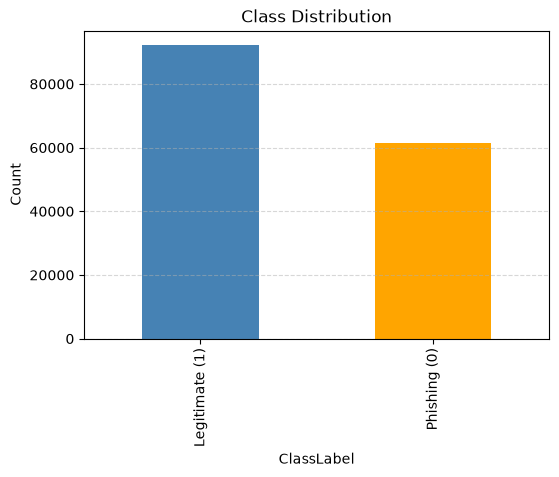

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['ClassLabel'].value_counts().plot(kind='bar', color=['steelblue','orange'])
plt.title("Class Distribution")
plt.xticks([0,1], ['Legitimate (1)','Phishing (0)'])
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


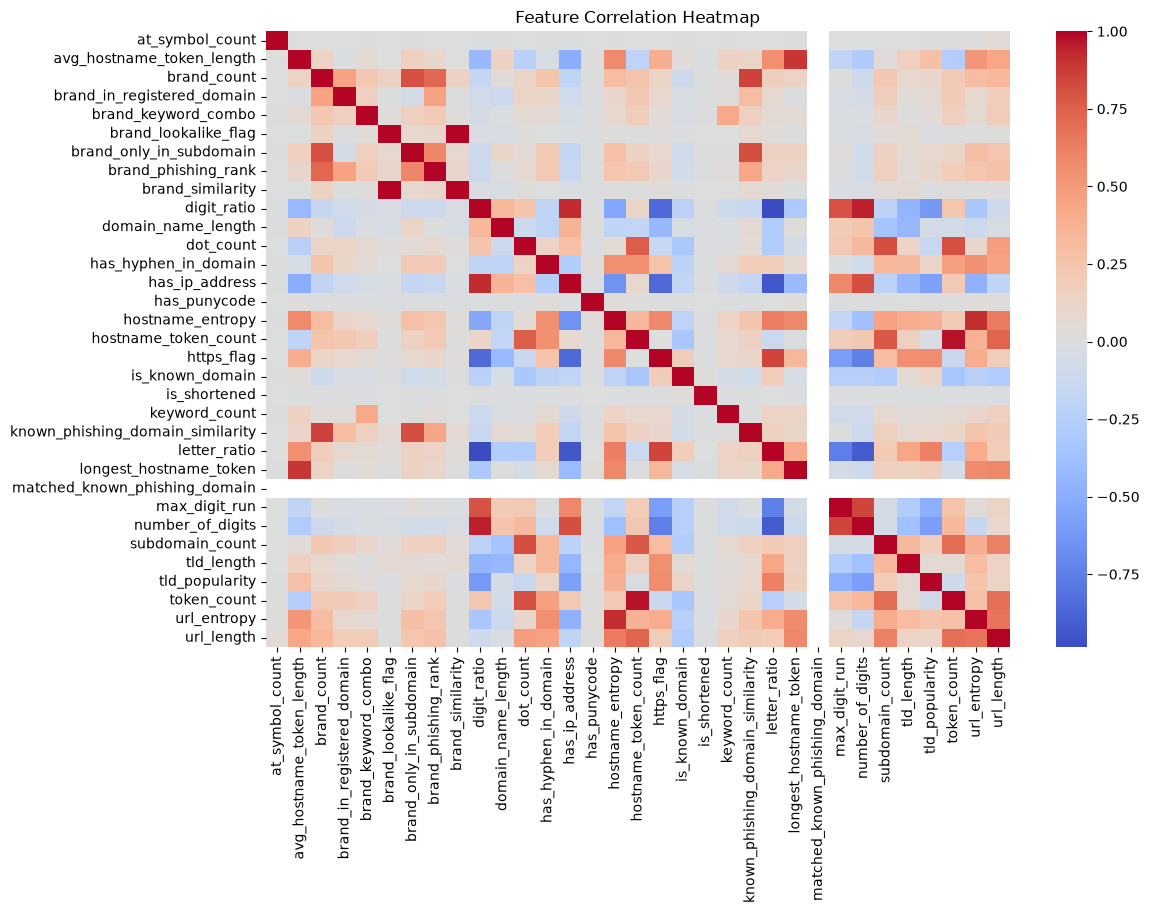

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df[FEATURE_COLS].corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


c:\Users\ASUS\Documents\Projects\aegis-project\notebookvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


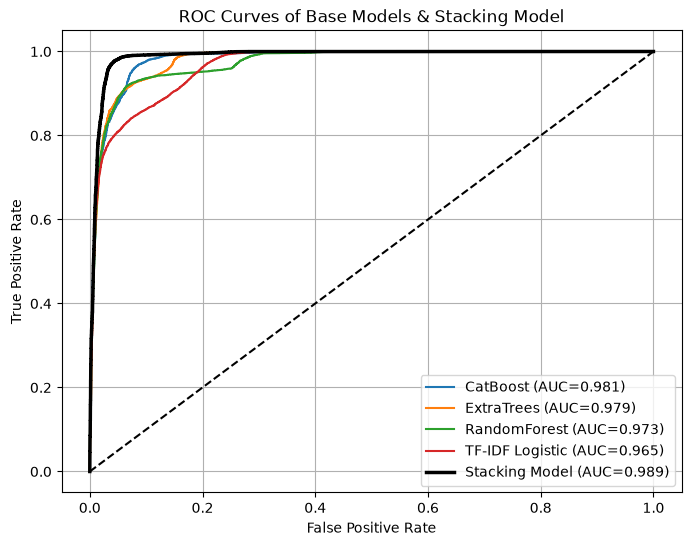

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

artifact = joblib.load(model_path)

plt.figure(figsize=(8,6))

models = {
    "CatBoost": artifact["base_cat"],
    "ExtraTrees": artifact["base_ext"],
    "RandomForest": artifact["base_rf"],
    "TF-IDF Logistic": artifact["base_tfidf"]
}

aucs_individual = {}

for name, estimator in models.items():
    if name == "TF-IDF Logistic":
        prob = estimator.predict_proba(
            artifact["tfidf_vectorizer"].transform(url_test.astype(str))
        )[:, 1]
    else:
        prob = estimator.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    aucs_individual[name] = roc_auc
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

auc_cat = aucs_individual["CatBoost"]
auc_et = aucs_individual["ExtraTrees"]
auc_rf = aucs_individual["RandomForest"]

meta_input = np.column_stack([
    models["CatBoost"].predict_proba(X_test)[:, 1],
    models["ExtraTrees"].predict_proba(X_test)[:, 1],
    models["RandomForest"].predict_proba(X_test)[:, 1],
    models["TF-IDF Logistic"].predict_proba(artifact["tfidf_vectorizer"].transform(url_test.astype(str)))[:, 1]
])

meta_scaled = artifact["meta_scaler"].transform(meta_input)
stack_proba = artifact["meta_lr"].predict_proba(meta_scaled)[:, 1]
fpr_s, tpr_s, _ = roc_curve(y_test, stack_proba)
auc_s = auc(fpr_s, tpr_s)

plt.plot(fpr_s, tpr_s, linewidth=2.5, label=f"Stacking Model (AUC={auc_s:.3f})", color="black")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Base Models & Stacking Model")
plt.legend()
plt.grid(True)
plt.show()

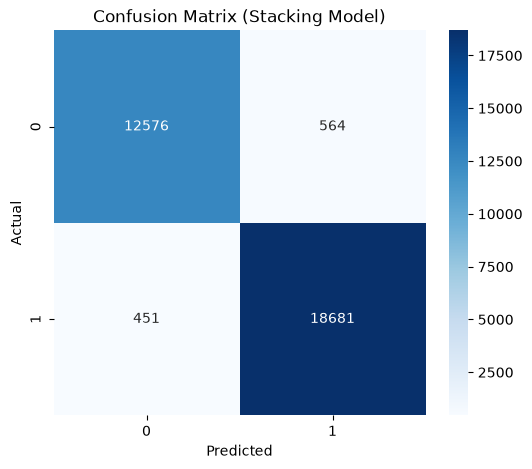

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = (stack_proba >= model['decision_threshold']).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Stacking Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


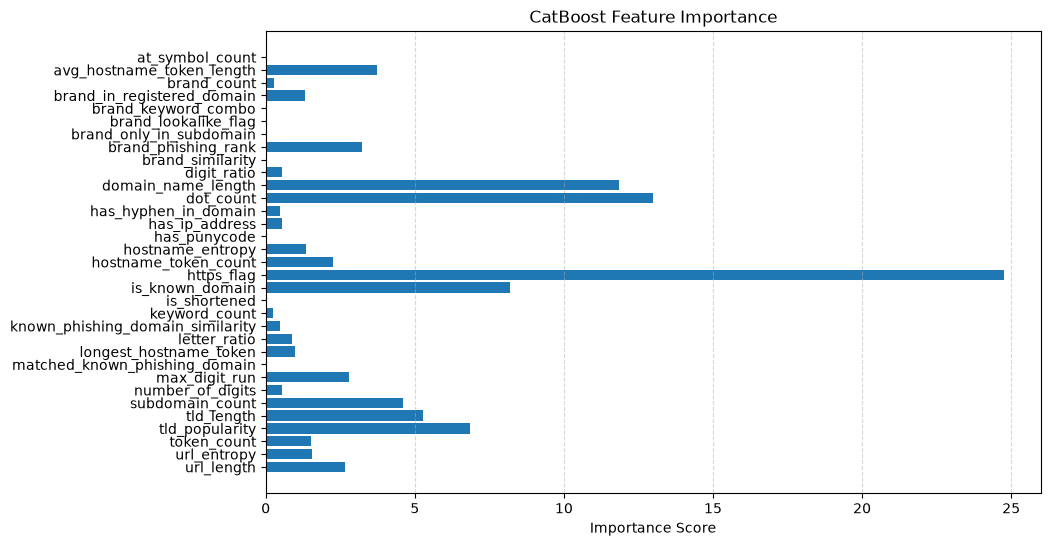

In [28]:
cat = artifact["base_cat"]

importances = cat.get_feature_importance()
features = artifact["feature_columns"]


plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


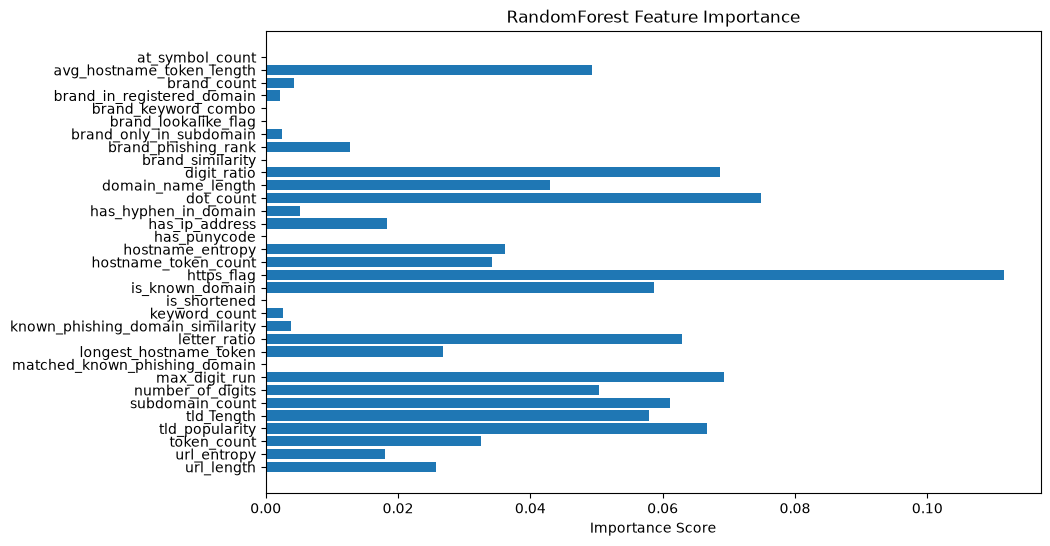

In [29]:
rf = artifact["base_rf"]
importances = rf.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()


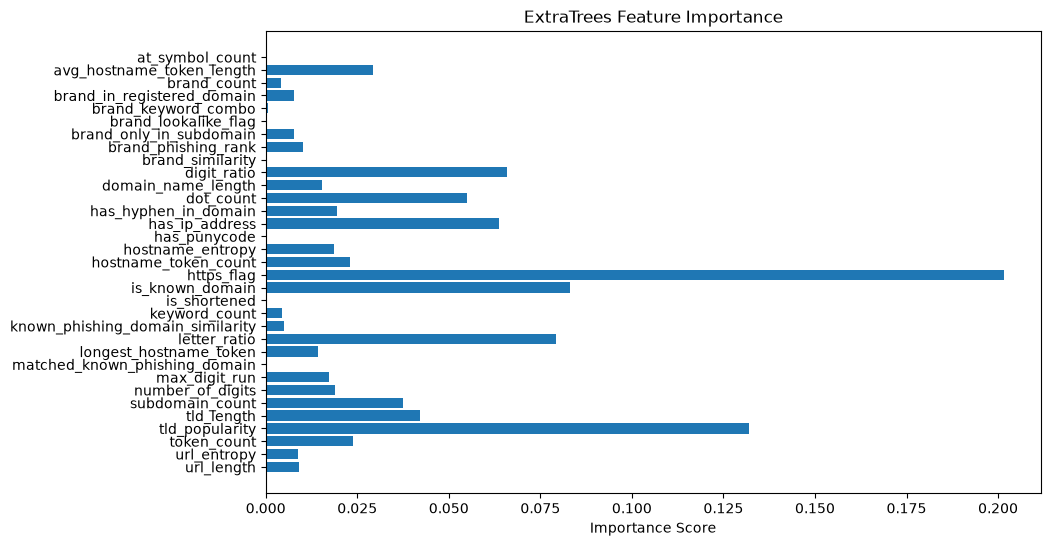

In [30]:
et = artifact["base_ext"]

importances = et.feature_importances_


plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("ExtraTrees Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()


In [31]:
from sklearn.metrics import roc_auc_score

proba_cat = artifact["base_cat"].predict_proba(X_test)[:, 1]
auc_cat = roc_auc_score(y_test, proba_cat)

proba_et = artifact["base_ext"].predict_proba(X_test)[:, 1]
auc_et = roc_auc_score(y_test, proba_et)

proba_rf = artifact["base_rf"].predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, proba_rf)


proba_tfidf = artifact["base_tfidf"].predict_proba(
artifact["tfidf_vectorizer"].transform(url_test.astype(str)))[:, 1]
auc_tfidf = roc_auc_score(y_test, proba_tfidf)
meta_input_test = np.column_stack([
    proba_cat,
    proba_et,
    proba_rf,
    proba_tfidf
])

meta_scaled_test = artifact["meta_scaler"].transform(meta_input_test)
auc_s = roc_auc_score(y_test, stack_proba )

print("CatBoost AUC:", auc_cat)
print("ExtraTrees AUC:", auc_et)
print("RandomForest AUC:", auc_rf)
print("Stacking AUC:", auc_s)


CatBoost AUC: 0.9808422881838933
ExtraTrees AUC: 0.9785080424200244
RandomForest AUC: 0.9725730075696173
Stacking AUC: 0.988807431253065


c:\Users\ASUS\Documents\Projects\aegis-project\notebookvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


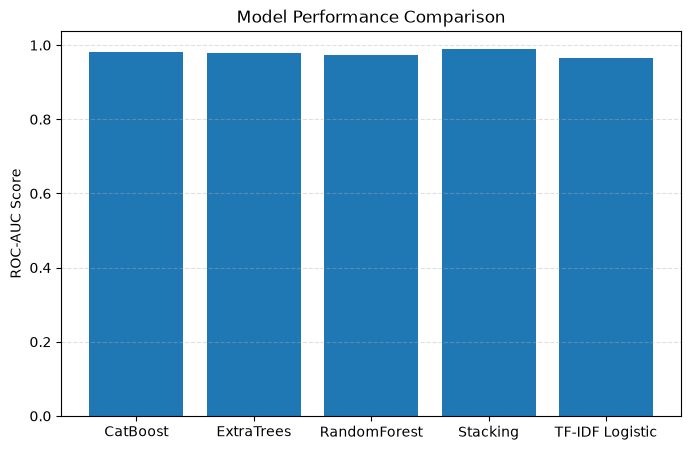

In [32]:
names = ["CatBoost", "ExtraTrees", "RandomForest", "Stacking", "TF-IDF Logistic"]
aucs = [auc_cat, auc_et, auc_rf, auc_s, auc_tfidf]

plt.figure(figsize=(8,5))
plt.bar(names, aucs)
plt.ylabel("ROC-AUC Score")
plt.title("Model Performance Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

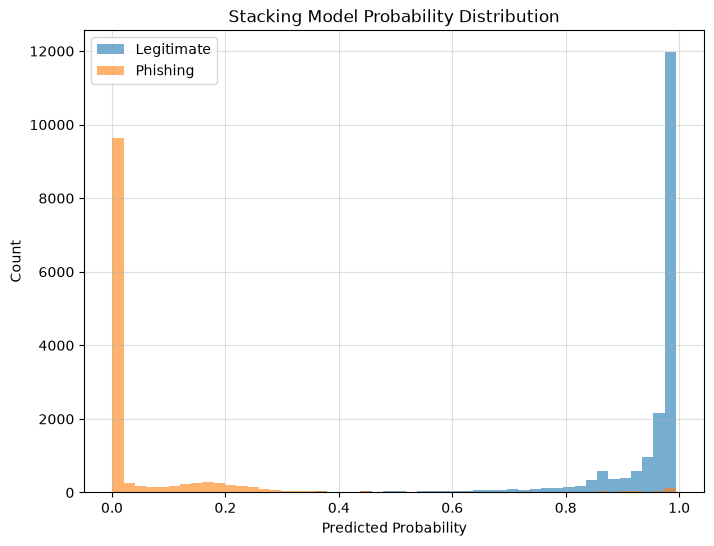

In [33]:
plt.figure(figsize=(8,6))

plt.hist(stack_proba [y_test==1], bins=50, alpha=0.6, label="Legitimate")
plt.hist(stack_proba [y_test==0], bins=50, alpha=0.6, label="Phishing")

plt.title("Stacking Model Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


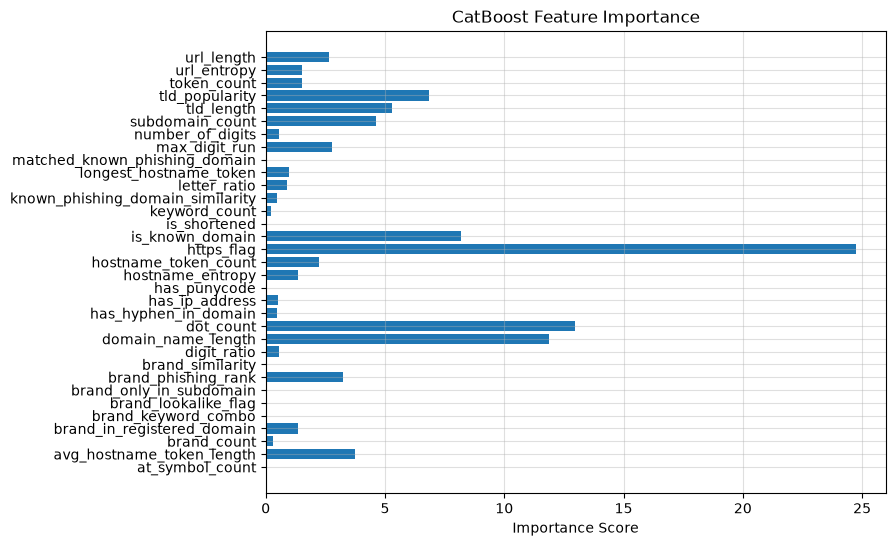

In [34]:
importances = artifact["base_cat"].get_feature_importance()
if len(features) != len(importances):
    if len(features) > len(importances):
        features = features[:len(importances)]
    else:
        features = features + [f"extra_{i}" for i in range(len(importances) - len(features))]
plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.grid(alpha=0.4)
plt.show()


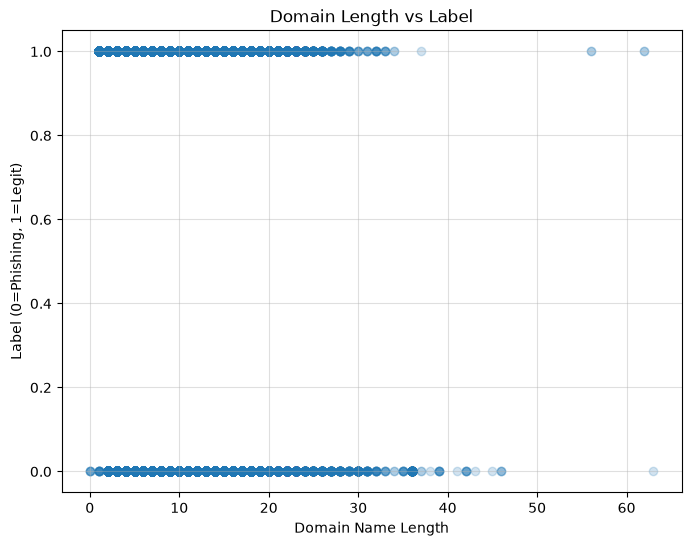

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(df['domain_name_length'], df['ClassLabel'], alpha=0.2)
plt.xlabel("Domain Name Length")
plt.ylabel("Label (0=Phishing, 1=Legit)")
plt.title("Domain Length vs Label")
plt.grid(alpha=0.4)
plt.show()


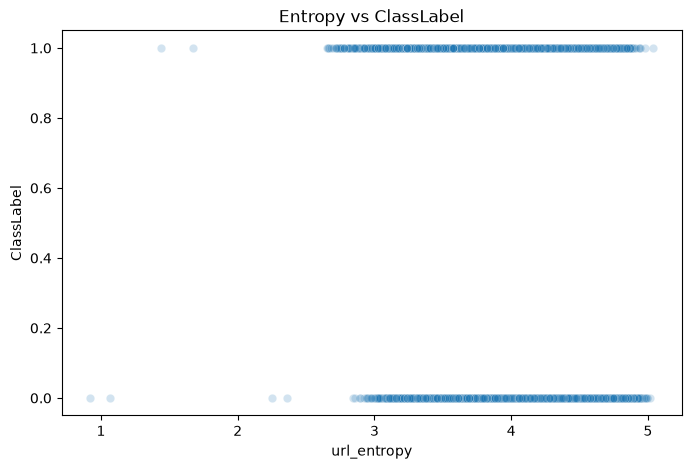

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["url_entropy"], y=df["ClassLabel"], alpha=0.2)
plt.title("Entropy vs ClassLabel")
plt.show()


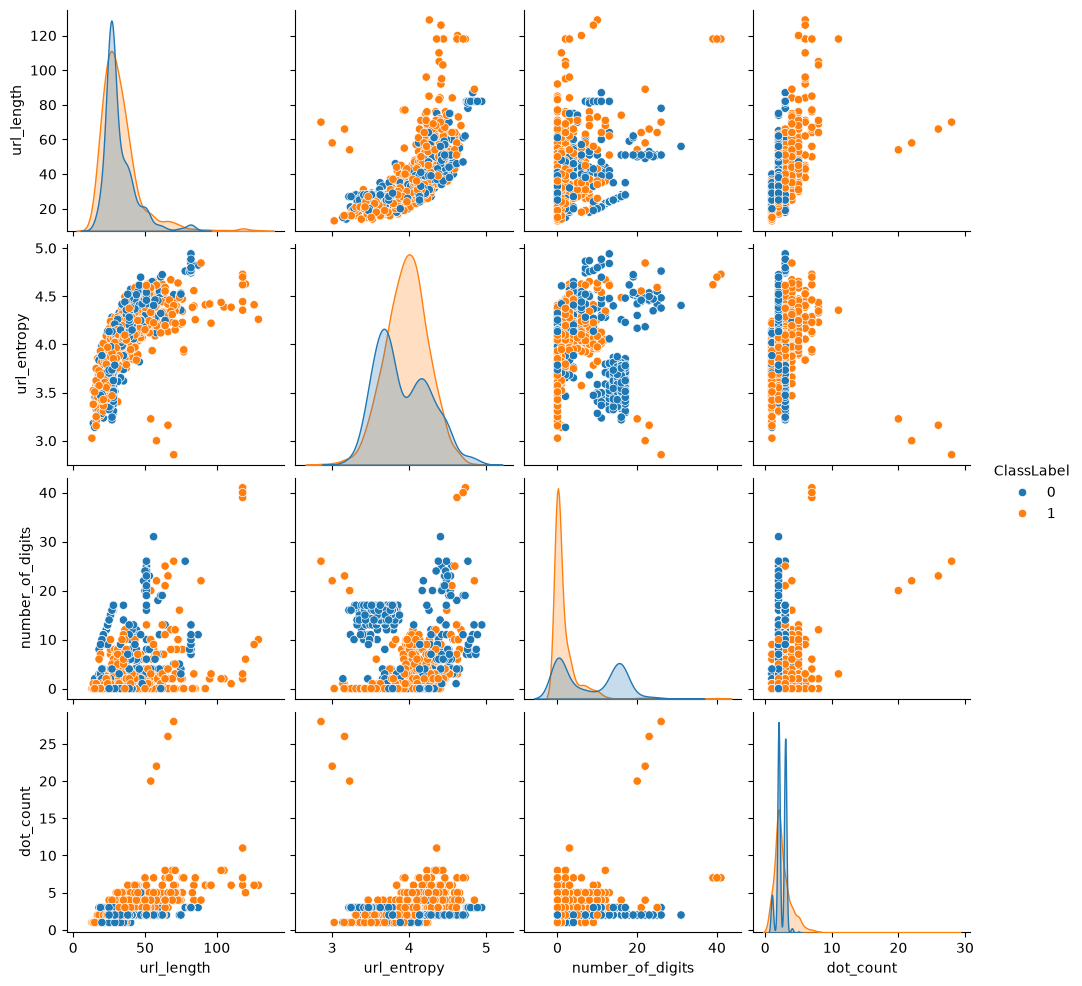

In [37]:
sns.pairplot(df.sample(2000), vars=["url_length","url_entropy","number_of_digits","dot_count"], hue="ClassLabel")
plt.show()

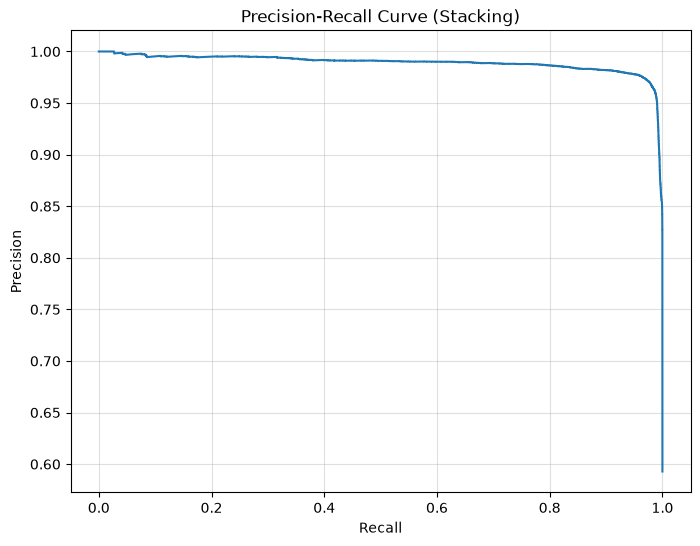

In [38]:
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, stack_proba )

plt.figure(figsize=(8,6))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve (Stacking)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.4)
plt.show()


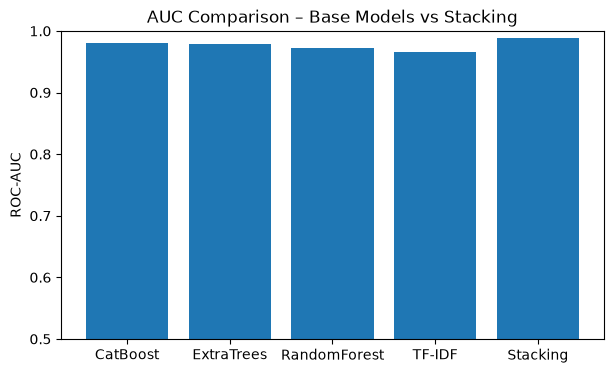

[0.9808422881838933, 0.9785080424200244, 0.9725730075696173, 0.9654988884401916, 0.988807431253065]


In [39]:
names = ["CatBoost", "ExtraTrees", "RandomForest", "TF-IDF","Stacking"]
aucs = [auc_cat, auc_et, auc_rf, auc_tfidf, auc_s]

plt.figure(figsize=(7,4))
plt.bar(names, aucs)
plt.ylim(0.5, 1)
plt.title("AUC Comparison – Base Models vs Stacking")
plt.ylabel("ROC-AUC")
plt.show()

print(aucs)


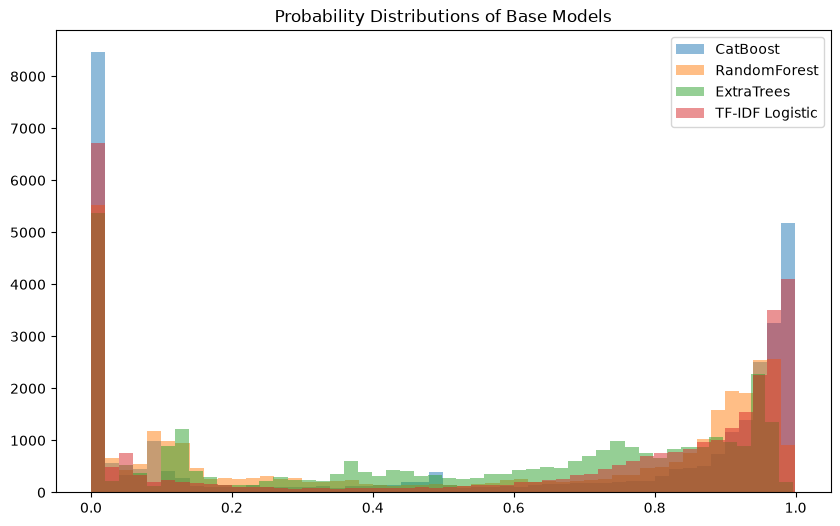

In [40]:
plt.figure(figsize=(10,6))
plt.hist(proba_cat, bins=50, alpha=0.5, label="CatBoost")
plt.hist(proba_rf, bins=50, alpha=0.5, label="RandomForest")
plt.hist(proba_et, bins=50, alpha=0.5, label="ExtraTrees")
plt.hist(proba_tfidf, bins=50, alpha=0.5, label="TF-IDF Logistic")
plt.legend()
plt.title("Probability Distributions of Base Models")
plt.show()


In [41]:

proba_cat_test = artifact["base_cat"].predict_proba(X_test)[:, 1]
proba_et_test  = artifact["base_ext"].predict_proba(X_test)[:, 1]
proba_rf_test  = artifact["base_rf"].predict_proba(X_test)[:, 1]

proba_tfidf_test = artifact["base_tfidf"].predict_proba(
    artifact["tfidf_vectorizer"].transform(url_test.astype(str)))[:, 1]

meta_test = np.column_stack([
    proba_cat_test,
    proba_et_test,
    proba_rf_test,
    proba_tfidf_test
])

meta_test_scaled = artifact["meta_scaler"].transform(meta_test)
stack_pred = (stack_proba  >= artifact["decision_threshold"]).astype(int)


c:\Users\ASUS\Documents\Projects\aegis-project\notebookvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


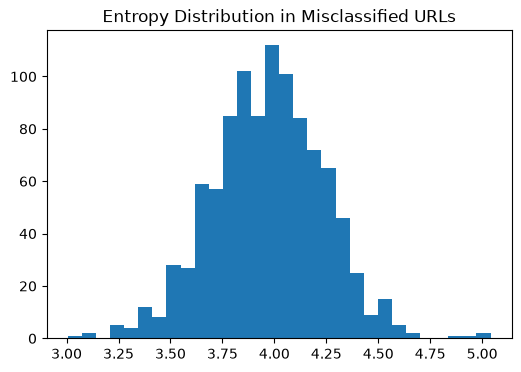

In [42]:
misclassified = X_test[stack_pred != y_test]
plt.figure(figsize=(6,4))
plt.hist(misclassified["url_entropy"], bins=30)
plt.title("Entropy Distribution in Misclassified URLs")
plt.show()


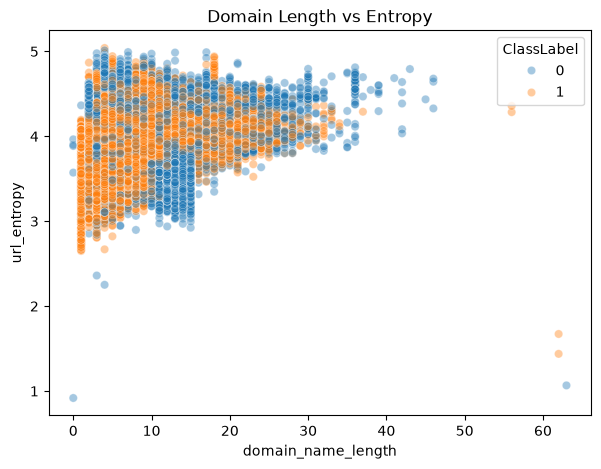

In [43]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["domain_name_length"], y=df["url_entropy"], hue=df["ClassLabel"], alpha=0.4)
plt.title("Domain Length vs Entropy")
plt.show()


In [44]:
meta = pd.DataFrame([{
    "cat_pred": 0.99,
    "ext_pred": 0.99,
    "rf_pred": 0.99,
    "tfidf_lr_pred": 0.99
}])

meta_scaled = artifact["meta_scaler"].transform(meta)

print(
    artifact["meta_lr"].predict_proba(meta_scaled)
)

[[0.00618045 0.99381955]]


In [45]:
urls = [
    "https://mail.google.com",
    "https://docs.google.com",
    "https://accounts.google.com",
    "https://drive.google.com",
    "https://developer.mozilla.org",
    "https://support.rnicrosoft.com",
    "https://api.github.com",
    "https://learn.microsoft.com",
    "https://docs.python.org",
    "https://aws.amazon.com"
]
for url in urls:
    result = predict_url(url)
    print(result)

{'url': 'https://mail.google.com', 'prob_phishing': 0.01307988071485855, 'prob_legitimate': 0.9869201192851415, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.9808347773977633, 'extratrees': 0.8675720337535762, 'randomforest': 0.8685792940751994, 'tfidf_logistic': 0.9192406678195418}}
{'url': 'https://docs.google.com', 'prob_phishing': 0.014027543865018477, 'prob_legitimate': 0.9859724561349815, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.9818863790015145, 'extratrees': 0.8688524466271929, 'randomforest': 0.8603587198075519, 'tfidf_logistic': 0.9091539605426312}}
{'url': 'https://accounts.google.com', 'prob_phishing': 0.017796090510594054, 'prob_legitimate': 0.982203909489406, 'prediction_label': 1, 'risk_level': 'Legitimate', 'base_model_scores': {'catboost': 0.9369721814686925, 'extratrees': 0.8539440744828384, 'randomforest': 0.7867851736818551, 'tfidf_logistic': 0.907219598932828}}
{'url': 'https://d